In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold,train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score


In [11]:
iris = load_iris()
data = pd.DataFrame(iris.data,columns=iris.feature_names)
data['target'] = iris.target 
print(data.head())

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  target
0                5.1               3.5  ...               0.2       0
1                4.9               3.0  ...               0.2       0
2                4.7               3.2  ...               0.2       0
3                4.6               3.1  ...               0.2       0
4                5.0               3.6  ...               0.2       0

[5 rows x 5 columns]


In [12]:
X = data.drop(columns='target')
y = data['target']
print(X.shape)
print(y.shape)

(150, 4)
(150,)


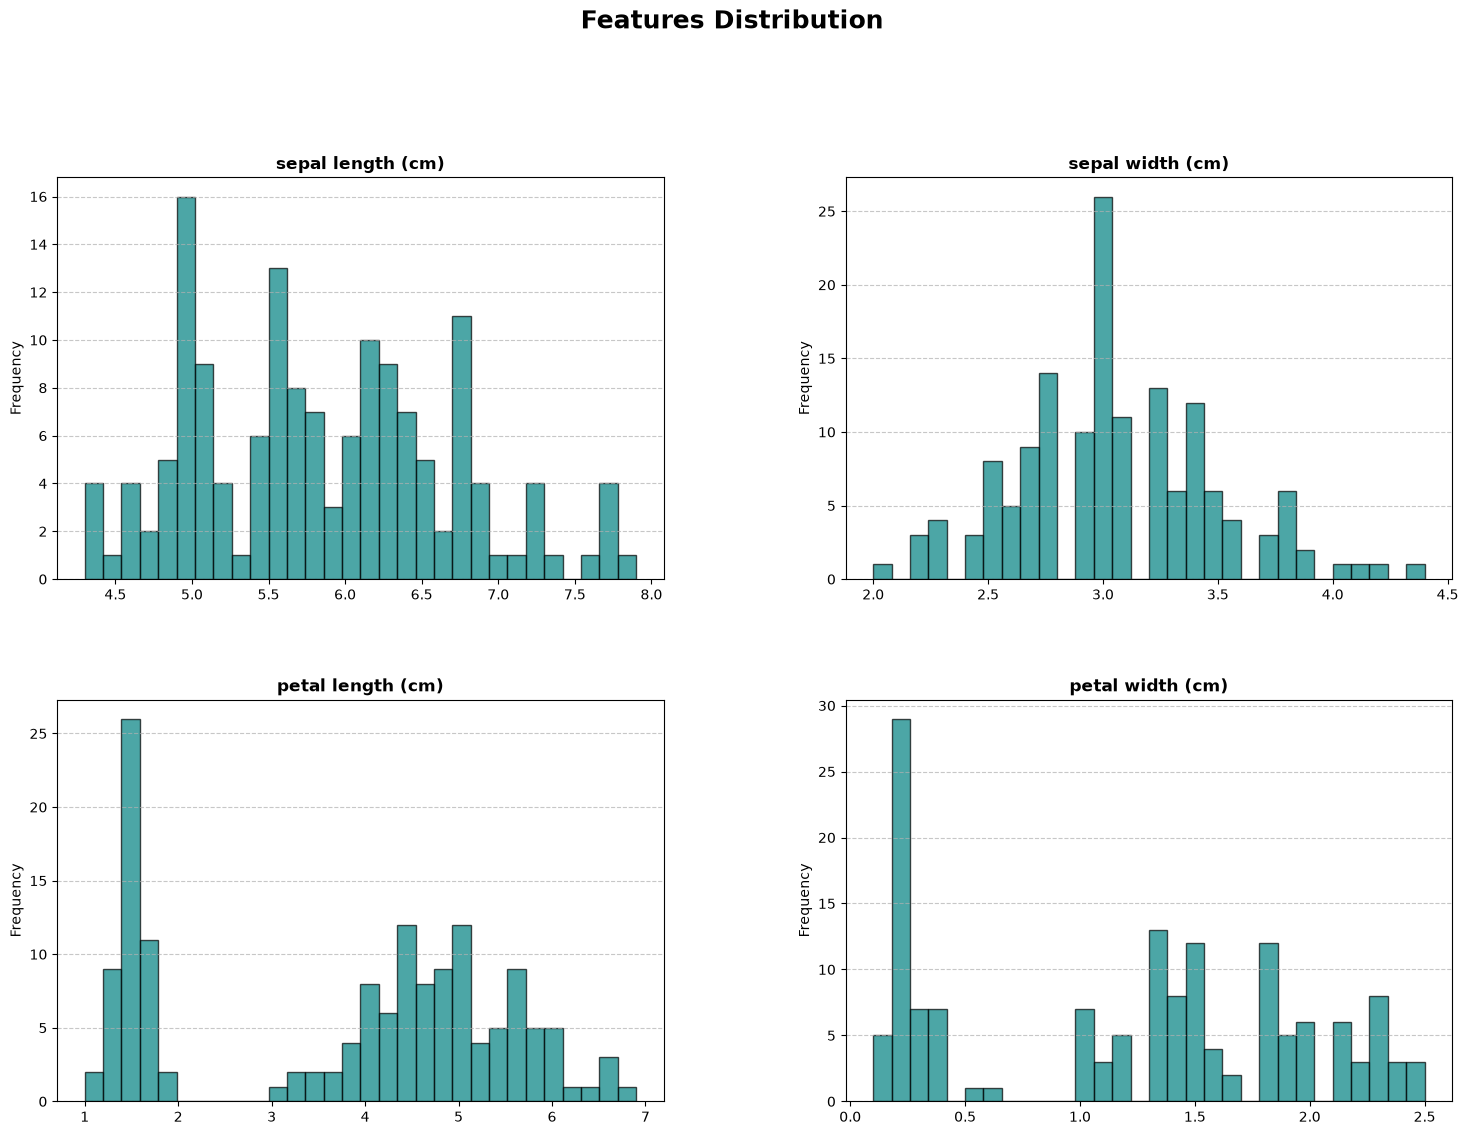

In [ ]:
import math
num_features = X_train.shape[1]
num_rows = math.ceil(num_features/2)

ax = X.hist(layout=(num_rows,2),figsize=(18,6*num_rows),bins = 30, edgecolor = 'black',color = 'teal',alpha = 0.7)
for ax in ax.flatten():
    ax.set_title(ax.get_title(),fontsize = 12,fontweight='bold')
    ax.set_ylabel('Frequency',fontsize = 10)
    ax.grid(axis = 'y',linestyle = '--',alpha = 0.7)
    ax.grid(axis = 'x', visible = False)
plt.suptitle("Features Distribution",fontsize = 18, fontweight = 'bold',y = 1.02)    
plt.tight_layout
plt.show()

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify=y,random_state = 42)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.tree import DecisionTreeClassifier
base_tree = DecisionTreeClassifier(random_state=42)
adb = AdaBoostClassifier(estimator= base_tree,random_state=42)
cv = StratifiedKFold(n_splits=5,shuffle = True,random_state=42)
cv_score = cross_val_score(adb,X_train_scaled,y_train,cv = cv , scoring='accuracy')
mean_accuracy = cv_score.mean()
print(mean_accuracy)

0.9416666666666667


In [17]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    #adaboost
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    
     # Base Decision Tree
    "estimator__max_depth": [1, 2, 3],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 5],
    "estimator__max_features": [None, "sqrt", "log2"]
}
grid_search = GridSearchCV(
    estimator = adb,
    cv = cv, 
    param_grid = param_grid,
    scoring = "f1_macro",
    error_score = 'raise',
    n_jobs = -1
)
grid_search.fit(X_train_scaled,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 2, ...], 'estimator__max_features': [None, 'sqrt', ...], 'estimator__min_samples_leaf': [1, 2, ...], 'estimator__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sp

In [18]:
print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

{'estimator__max_depth': 1, 'estimator__max_features': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'learning_rate': 0.1, 'n_estimators': 100}
0.9747027699968877


In [19]:
y_pred = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9666666666666667


In [20]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    
     # Base Decision Tree
    "estimator__max_depth": [1, 2, 3],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 5],
    "estimator__max_features": [None, "sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator = adb,
    param_distributions = param_dist,
    cv = cv,
    n_iter = 1000,
    scoring = "f1_macro",
    random_state = 42,
    error_score = 'raise',
    n_jobs = -1
    
)
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__max_depth': [1, 2, ...], 'estimator__max_features': [None, 'sqrt', ...], 'estimator__min_samples_leaf': [1, 2, ...], 'estimator__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whi

In [21]:
print(random_search.best_params_)
print(random_search.best_score_)

best_model = random_search.best_estimator_

{'n_estimators': 100, 'learning_rate': 0.1, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 2, 'estimator__max_features': None, 'estimator__max_depth': 1}
0.9747027699968877


In [22]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9666666666666667


In [24]:
from skopt.space import Integer, Real, Categorical
from skopt import BayesSearchCV
search_spaces = {
    "n_estimators": Integer(50, 200),
    "learning_rate": Real(0.01, 1.0, prior="log-uniform"),
    "estimator__max_depth": Integer(1, 3),
    "estimator__min_samples_split": Integer(2, 10),
    "estimator__min_samples_leaf": Integer(1, 5),
    "estimator__max_features": Categorical([None, "sqrt", "log2"])
}
bayes_search = BayesSearchCV(
    estimator = adb,
    search_spaces = search_spaces,
    n_iter = 100,
    cv = cv, 
    scoring = "f1_macro",
    error_score = "raise",
    random_state = 42,
    n_jobs = -1
)

bayes_search.fit(X_train_scaled,y_train)

,estimator,AdaBoostClass...ndom_state=42)
,search_spaces,"{'estimator__max_depth': Integer(low=1...m='normalize'), 'estimator__max_features': Categorical(c...), prior=None), 'estimator__min_samples_leaf': Integer(low=1...m='normalize'), 'estimator__min_samples_split': Integer(low=2...m='normalize'), ...}"
,n_iter,100
,scoring,'f1_macro'
,n_jobs,-1
,cv,StratifiedKFo... shuffle=True)
,random_state,42
,optimizer_kwargs,None
,fit_params,None
,n_points,1
,iid,'deprecated'


In [25]:
print(bayes_search.best_params_)
print(bayes_search.best_score_)

best_model = bayes_search.best_estimator_

OrderedDict({'estimator__max_depth': 1, 'estimator__max_features': None, 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 10, 'learning_rate': 0.06571978136115963, 'n_estimators': 200})
0.9747027699968877


In [26]:
y_pre = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9666666666666667
